### Student Placements Predictoin

#### Business Problem

- The business problem is to predict whether the college student will secure a job based on academic and extracurriculars. This is important for a recruitment consultancy and educational institution to identify and enhance placement rates, and provide support, benefiting the company by improving client satisfaction and revenue.

#### Objective
- To Develope a machine learning model that can accurately classify students into placed or not placed categories based on features like academic performance and internships or other skills.

### Data Collection
- Data source:- the dataset was collected form kaggle. it contains 10000 students with various 10 attributes and it might influence their placement status.
- https://www.kaggle.com/datasets/sahilislam007/college-student-placement-factors-dataset

### Feature Explanation:-
- College ID :- A Unique Identifier for college
- IQ:- Numerical score of the brain
- Prev_Sem_Result:- Privious semesters marks
- CGPA : Cumulative Grade Point Average
- Academic_Performance:- A performance score of term
- Internship_Experience:- Categorical(yes or no)
- Extra_curricular_Score:- Numerical score
- Communication_Skills:- Numerical Score
- Project_Completed:- Count of Projects
- PlaceMent:- the target variable we have to predict

### Data Cleaning and Preprocessing

#### First we will load the data

In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv('college_student_placement_dataset.csv')

##### Handling the missing values if appears or ensuring the dataset is clean

In [3]:
print(df.isnull().sum())

College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64


#### Handle the duplicated data if it containes then drop 

In [4]:
print("Duplicate data: ",df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate data:  0


#### machine learning models can use numrical data from any datatype like string or categorical and dropping the irrelevant column

In [5]:
df['Internship_Experience'] = df['Internship_Experience'].map({'Yes': 1, 'No': 0})
df['Placement'] = df['Placement'].map({'Yes': 1, 'No': 0})
df = df.drop(columns=['College_ID'])

### Data Exploration and Analysis
- This step is crucial to understand patterns, relationship and distribution of data

Placement
0    8341
1    1659
Name: count, dtype: int64


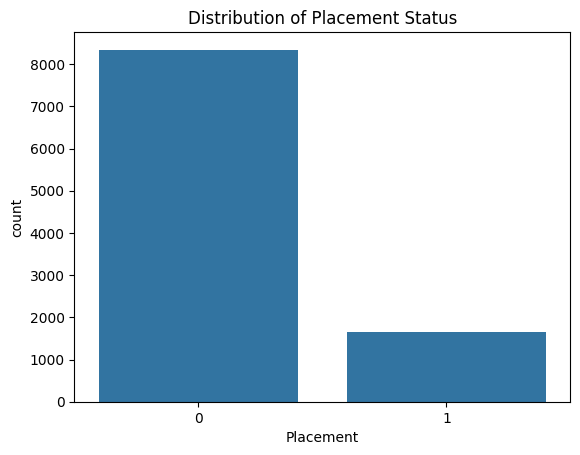

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
print(df['Placement'].value_counts())
sns.countplot(x='Placement', data=df)
plt.title('Distribution of Placement Status')
plt.show()

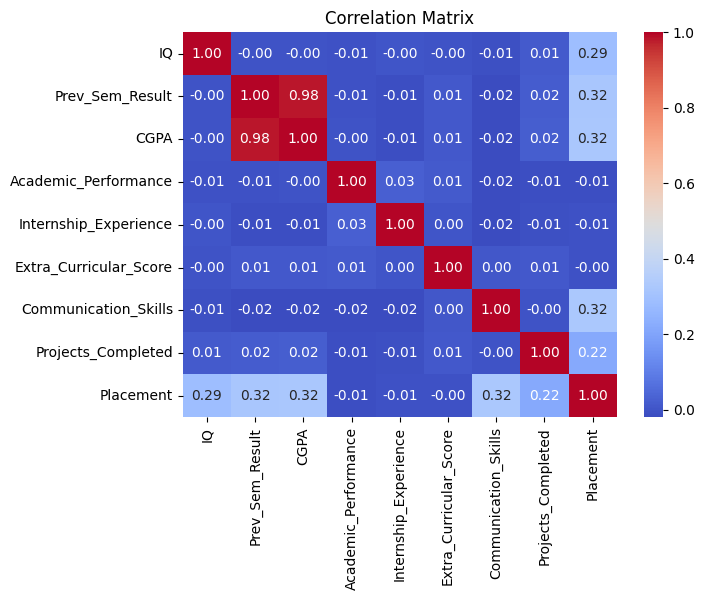

In [7]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

- Correalation analyzing between CGPA, Communication_Skills, and Placement, and it can be rate by internship Experience.

### Checking the correlation analysis

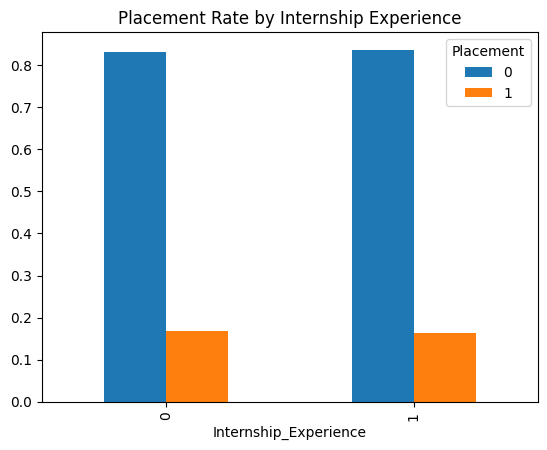

In [8]:
pd.crosstab(df['Internship_Experience'], df['Placement'], normalize='index').plot(kind='bar')
plt.title('Placement Rate by Internship Experience')
plt.show()

### Feature Engineering 
- We will create a new feature it can be more predictive
- we will combine `CGPA` and `Communication_skills` and `academic_performance`  with `project_completed`
- We will combine Iq and Extracurricular and create a new strong feature


In [9]:
df['CGPA_Comm_Skills'] = df['CGPA'] * df['Communication_Skills']
df['Academic_Projects'] = df['Academic_Performance'] + df['Projects_Completed']
df['IQ_ExtraCurricular'] = df['IQ'] * df['Extra_Curricular_Score']

print(df[['IQ_ExtraCurricular','CGPA_Comm_Skills','Academic_Projects']].head())

   IQ_ExtraCurricular  CGPA_Comm_Skills  Academic_Projects
0                 856             50.24                 12
1                 679             42.96                  8
2                 327              5.83                 10
3                 122             34.50                  7
4                 768             76.90                  9


### Build prediction models
- to train models we will split data into x training and y testing
- for that we must drop the target because it will create a bad training.
  

In [10]:
X = df.drop('Placement', axis=1)
y = df['Placement']

#### Split Dataset into training 80% and testing 20%:-

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Train multiple models
- For this dataset we will train multiple models using python dictionary datatype
 and we will select which model is best 

In [12]:
print(X.dtypes)

IQ                          int64
Prev_Sem_Result           float64
CGPA                      float64
Academic_Performance        int64
Internship_Experience       int64
Extra_Curricular_Score      int64
Communication_Skills        int64
Projects_Completed          int64
CGPA_Comm_Skills          float64
Academic_Projects           int64
IQ_ExtraCurricular          int64
dtype: object


### Evaluation of the models

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))


--- Training Logistic Regression ---
Accuracy: 0.9020
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1668
           1       0.77      0.58      0.66       332

    accuracy                           0.90      2000
   macro avg       0.85      0.77      0.80      2000
weighted avg       0.90      0.90      0.90      2000


--- Training Random Forest ---
Accuracy: 0.9995
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1668
           1       1.00      1.00      1.00       332

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


--- Training Support Vector Machine ---
Accuracy: 0.9555
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1668
           1       0.92      0.80      0.86       332

    accuracy        

### Model Evaluation Selection and model tuning


In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


### Deployment of best model

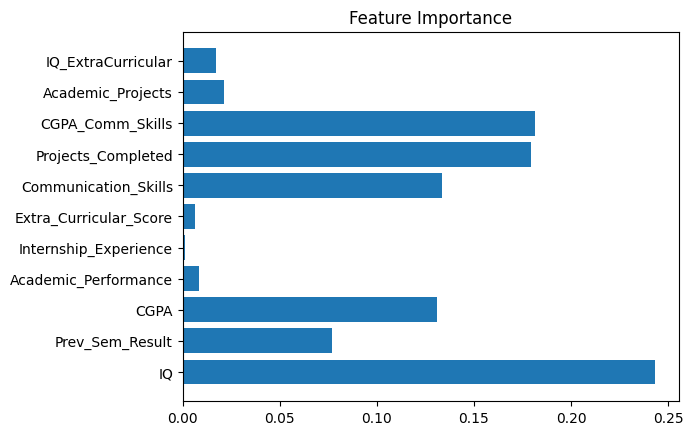

In [73]:

feature_importances = best_model.feature_importances_
features = X.columns
plt.barh(features, feature_importances)
plt.title('Feature Importance')
plt.show()

- above figure describe the importance of the fetures and that can be powerful for predictions. we can see that if a student has Distinct CGPA, Communication skills and projects done can get Job easily in market.

#### To save the model 

In [74]:
import joblib
joblib.dump(best_model, 'placement_predictor_model.pkl')

['placement_predictor_model.pkl']

### Conclusion
- Strenghts: The pipeline is comprehensive with high accuracy from random forest and handling imbalance stratification. Predictions improved using features engineering
- Limitation: Dataset imbalance can affect minority class and overfitting risk despite tuning
- Implications: Helps target support for student, boosting placement rates and revenue.
- Recommoendations: Deploy model for real-time prediction monitoring with data. Most Informative fetures like CGPA_Comm_Skills and IQ and Extracurricular.